In [2]:
from os.path import join
import numpy as np
import matplotlib.pyplot as plt

def load_data(load_dir, bid):
    SIZE = 512
    u = np.zeros((SIZE + 2, SIZE + 2))
    u[1:-1, 1:-1] = np.load(join(load_dir, f"{bid}_domain.npy"))
    interior_mask = np.load(join(load_dir, f"{bid}_interior.npy"))
    return u, interior_mask


def jacobi(u, interior_mask, max_iter, atol=1e-6):
    u = np.copy(u)

    for i in range(max_iter):
        # Compute average of left, right, up and down neighbors, see eq. (1)
        u_new = 0.25 * (u[1:-1, :-2] + u[1:-1, 2:] + u[:-2, 1:-1] + u[2:, 1:-1])
        u_new_interior = u_new[interior_mask]
        delta = np.abs(u[1:-1, 1:-1][interior_mask] - u_new_interior).max()
        u[1:-1, 1:-1][interior_mask] = u_new_interior

        if delta < atol:
            break
    return u


def summary_stats(u, interior_mask):
    u_interior = u[1:-1, 1:-1][interior_mask]
    mean_temp = u_interior.mean()
    std_temp = u_interior.std()
    pct_above_18 = np.sum(u_interior > 18) / u_interior.size * 100
    pct_below_15 = np.sum(u_interior < 15) / u_interior.size * 100
    return {
        'mean_temp': mean_temp,
        'std_temp': std_temp,
        'pct_above_18': pct_above_18,
        'pct_below_15': pct_below_15,
    }

# Task 1

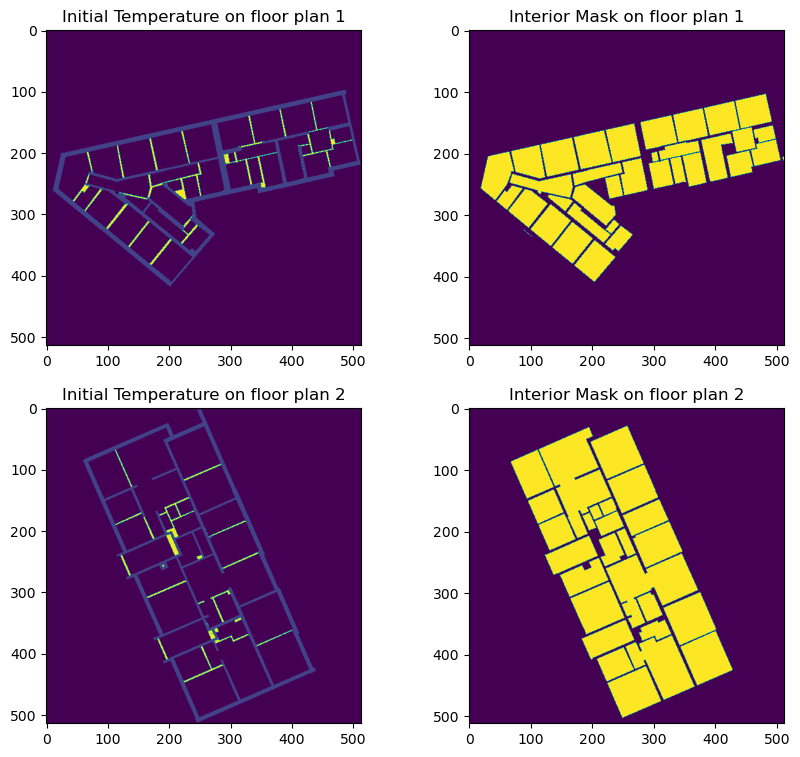

In [8]:
# Load data
LOAD_DIR = '/dtu/projects/02613_2025/data/modified_swiss_dwellings/'
with open(join(LOAD_DIR, 'building_ids.txt'), 'r') as f:
    building_ids = f.read().splitlines()
N = 2
building_ids = building_ids[:N]

# Load floor plans
all_u0 = np.empty((N, 514, 514))
all_interior_mask = np.empty((N, 512, 512), dtype='bool')
for i, bid in enumerate(building_ids):
    u0, interior_mask = load_data(LOAD_DIR, bid)
    all_u0[i] = u0
    all_interior_mask[i] = interior_mask

fig, ax = plt.subplots(N, 2, figsize=(10, 9), squeeze=False)
for i in range(N):
    ax[i, 0].imshow(all_u0[i])
    ax[i, 0].set_title(f'Initial Temperature on floor plan {i+1}')
    ax[i, 1].imshow(all_interior_mask[i])
    ax[i, 1].set_title(f'Interior Mask on floor plan {i+1}')


# Task 2

```
#!/bin/sh 
### General options 
### -- specify queue -- 
#BSUB -q hpc
### -- set the job Name -- 
#BSUB -J miniproject_job
### -- ask for number of cores (default: 1) -- 
#BSUB -n 1
### -- specify that the cores must be on the same host -- 
#BSUB -R "span[hosts=1]"
### -- specify that we need 4GB of memory per core/slot -- 
#BSUB -R "rusage[mem=5GB]"
#BSUB -R "select[model==XeonGold6126]"
### -- set walltime limit: hh:mm -- 
#BSUB -W 15
### -- send notification at start -- 
#BSUB -B 
### -- send notification at completion -- 
#BSUB -N 
### -- Specify the output and error file. %J is the job-id -- 
### -- -o and -e mean append, -oo and -eo mean overwrite -- 
#BSUB -o Output_%J.out 
#BSUB -e Output_%J.err 

# here follow the commands you want to execute with input.in as the input file
source /dtu/projects/02613_2025/conda/conda_init.sh

conda activate 02613

export N=20
echo "Running simulation with N=$N floor plans"
time python3 simulate.py $N
```

Task 3

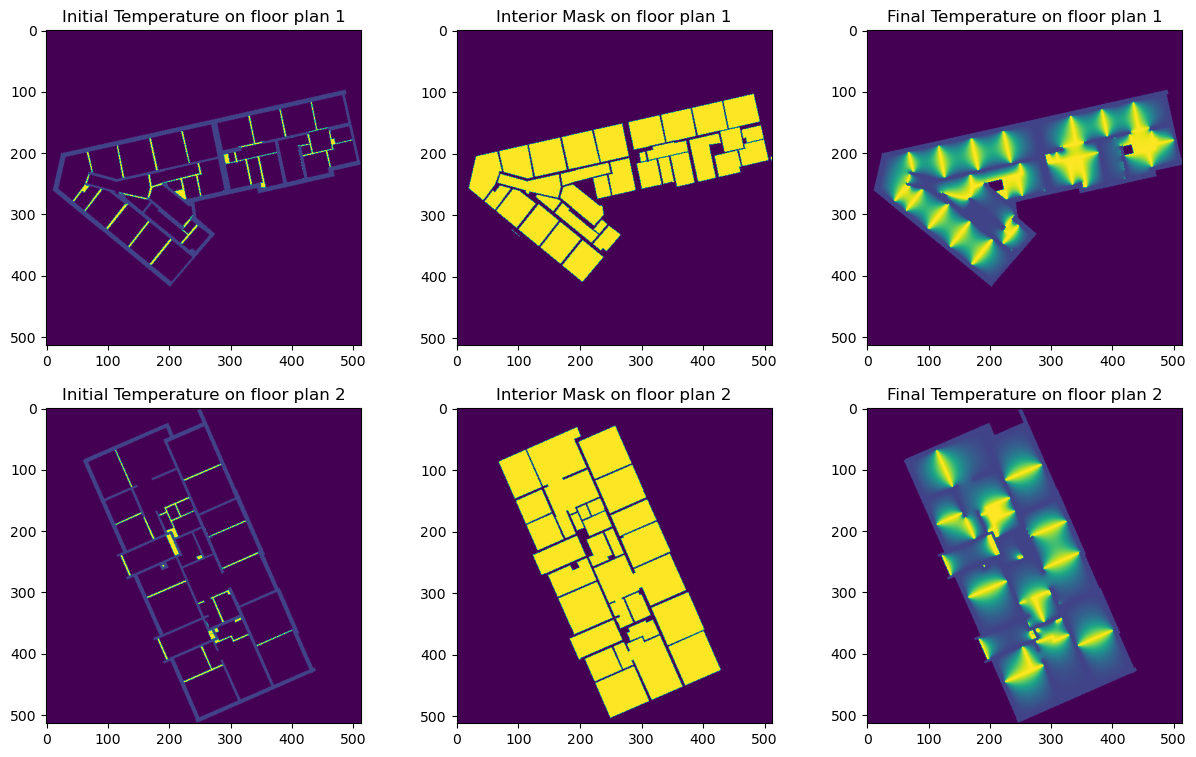

In [9]:
# Load data
all_u = np.empty((N, 514, 514))
for i, bid in enumerate(building_ids):
    all_u[i] = np.load(f'output/u{i}.npy')

fig, ax = plt.subplots(N, 3, figsize=(15, 9), squeeze=False)
for i in range(N):
    ax[i, 0].imshow(all_u0[i])
    ax[i, 0].set_title(f'Initial Temperature on floor plan {i+1}')
    ax[i, 1].imshow(all_interior_mask[i])
    ax[i, 1].set_title(f'Interior Mask on floor plan {i+1}')
    ax[i, 2].imshow(all_u[i])
    ax[i, 2].set_title(f'Final Temperature on floor plan {i+1}')


Task 4
```
n-62-27-20(s224375) $ python -m line_profiler -rmt "simulate.py.lprof"
Timer unit: 1e-06 s

Total time: 5.95895 s
File: simulate.py
Function: jacobi at line 15

Line #      Hits         Time  Per Hit   % Time  Line Contents
==============================================================
    15                                           @profile
    16                                           def jacobi(u, interior_mask, max_iter, atol=1e-6):
    17         1        714.2    714.2      0.0      u = np.copy(u)
    18                                           
    19      3602       1654.8      0.5      0.0      for i in range(max_iter):
    20                                                   # Compute average of left, right, up and down neighbors, see eq. (1)
    21      3602    3939150.6   1093.6     66.1          u_new = 0.25 * (u[1:-1, :-2] + u[1:-1, 2:] + u[:-2, 1:-1] + u[2:, 1:-1])
    22      3602     523715.9    145.4      8.8          u_new_interior = u_new[interior_mask]
    23      3602     935891.1    259.8     15.7          delta = np.abs(u[1:-1, 1:-1][interior_mask] - u_new_interior).max()
    24      3602     554706.7    154.0      9.3          u[1:-1, 1:-1][interior_mask] = u_new_interior
    25                                           
    26      3602       3117.4      0.9      0.1          if delta < atol:
    27         1          0.4      0.4      0.0              break
    28         1          0.2      0.2      0.0      return u

  5.96 seconds - simulate.py:15 - jacobi
```

In [ ]:
# Load data
LOAD_DIR = '/dtu/projects/02613_2025/data/modified_swiss_dwellings/'
with open(join(LOAD_DIR, 'building_ids.txt'), 'r') as f:
    building_ids = f.read().splitlines()
N = 1
building_ids = building_ids[:N]

# Load floor plans
all_u0 = np.empty((N, 514, 514))
all_interior_mask = np.empty((N, 512, 512), dtype='bool')
for i, bid in enumerate(building_ids):
    u0, interior_mask = load_data(LOAD_DIR, bid)
    all_u0[i] = u0
    all_interior_mask[i] = interior_mask

# Run jacobi iterations for each floor plan
MAX_ITER = 20_000
ABS_TOL = 1e-4

all_u = np.empty_like(all_u0)
for i, (u0, interior_mask) in enumerate(zip(all_u0, all_interior_mask)):
    u = jacobi(u0, interior_mask, MAX_ITER, ABS_TOL)
    all_u[i] = u

# Print summary statistics in CSV format
stat_keys = ['mean_temp', 'std_temp', 'pct_above_18', 'pct_below_15']
print('building_id, ' + ', '.join(stat_keys))  # CSV header
for bid, u, interior_mask in zip(building_ids, all_u, all_interior_mask):
    stats = summary_stats(u, interior_mask)
    print(f"{bid},", ", ".join(str(stats[k]) for k in stat_keys))

## Task 5

```bash
for num_workers in 1 2 3 4 6 8 12 18 24
do
    time python3 -u simulate_5.py $N $num_workers
done
```
real	4m29.680s
user	4m28.456s
sys	0m0.966s

real	2m27.673s
user	4m29.892s
sys	0m0.658s

real	1m47.169s
user	4m47.857s
sys	0m0.735s

real	1m26.265s
user	5m5.830s
sys	0m0.716s

real	1m23.639s
user	5m12.924s
sys	0m0.872s

real	1m32.859s
user	5m24.295s
sys	0m1.004s

real	1m36.823s
user	5m26.077s
sys	0m0.951s

real	1m28.474s
user	5m21.636s
sys	0m1.120s

real	1m27.656s
user	5m40.431s
sys	0m1.377s

Fitted serial fraction f: 0.2618


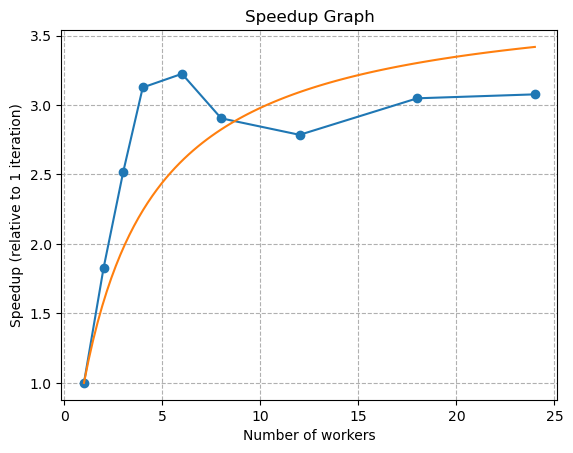

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
def amdahl(f, p):
    """
    f: fraction of the code that is serial (not parallelizable)
    p: number of processors (workers)
    """
    return 1 / (f + (1 - f) / p)
m = np.array([
    [1, 269.680],   # 279.661s
    [2, 147.673],   # 156.358s
    [3, 107.169],   # 108.143s
    [4, 86.265],    # 87.540s
    [6, 83.639],    # 87.556s
    [8, 92.859],    # 86.784s
    [12,96.823],    # 89.991s
    [18,88.474],    # 99.475s
    [24,87.656],    # 127.155s
])
m[:, 1] = m[0, 1] / m[:, 1]  # Convert seconds to minutes
x = np.linspace(1, 24, 100)
# fit the curve to the data to find the best f
from scipy.optimize import curve_fit
popt, _ = curve_fit(lambda p, f: amdahl(f, p), m[:, 0], m[:, 1], bounds=(0, 1))
f_fit = popt[0]
print(f"Fitted serial fraction f: {f_fit:.4f}")
y = amdahl(f_fit, x)

plt.plot(m[:, 0], m[:, 1], 'o-')
plt.plot(x, y, '-')  # Plot the theoretical curve
plt.xlabel('Number of workers')
plt.ylabel('Speedup (relative to 1 iteration)')
plt.title('Speedup Graph')
plt.grid(True, which="both", ls="--")
plt.show()

In [ ]:
# Theoretical speedup curve for f=0.47
1/(0.2618)
# Time to run for all processes
4571/24*83

(3.8197097020626436, 15808.041666666668)

## Dynamic scheduling

```

real	4m39.661s
user	4m38.671s
sys	0m0.521s

real	2m36.358s
user	4m36.656s
sys	0m0.538s

real	1m48.143s
user	5m5.471s
sys	0m0.622s

real	1m27.540s
user	5m12.644s
sys	0m0.602s

real	1m27.556s
user	5m12.329s
sys	0m0.700s

real	1m26.784s
user	5m20.860s
sys	0m0.841s

real	1m29.991s
user	5m30.997s
sys	0m1.023s

real	1m39.475s
user	5m31.449s
sys	0m1.042s

real	2m7.155s
user	5m34.104s
sys	0m1.216s
```

279.661s
156.358s
108.143s
87.540s
87.556s
86.784s
89.991s
99.475s
127.155s

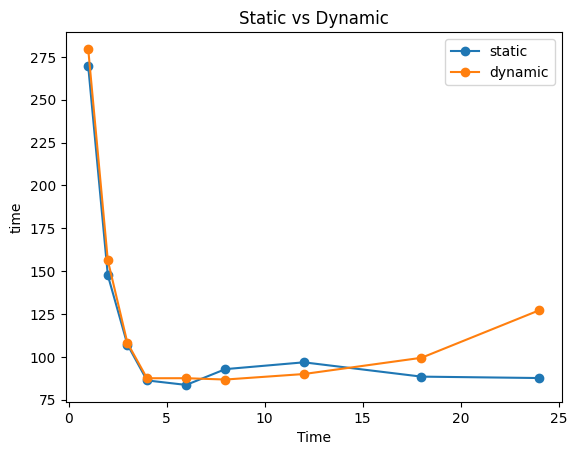

In [3]:
import numpy as np
import matplotlib.pyplot as plt
m = np.array([
    [1, 269.680, 279.661],
    [2, 147.673, 156.358],
    [3, 107.169, 108.143],
    [4, 86.265, 87.540],
    [6, 83.639, 87.556],
    [8, 92.859, 86.784],
    [12,96.823, 89.991],
    [18,88.474, 99.475],
    [24,87.656, 127.155]
])
plt.plot(m[:, 0], m[:, 1], 'o-', label='static')
plt.plot(m[:, 0], m[:, 2], 'o-', label='dynamic')
plt.xlabel('Time')
plt.ylabel('time')
plt.title('Static vs Dynamic')
plt.legend()
plt.show()

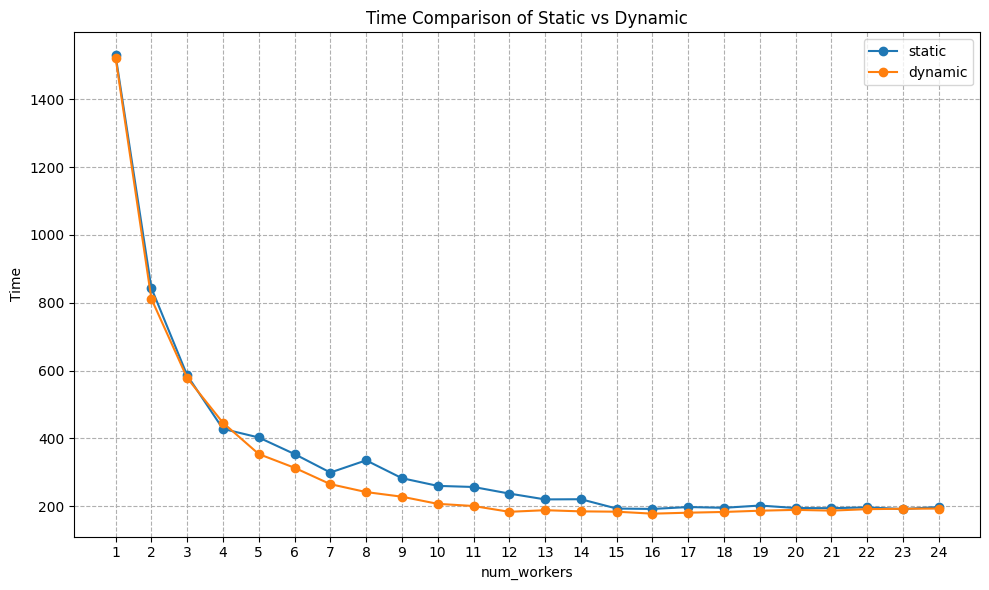

In [3]:
import numpy as np
import matplotlib.pyplot as plt
static_scheduling = np.array([
        1529.822,  843.585,  586.013,  428.083,  402.75 ,  353.868,
        299.354,  335.367,  282.723,  260.041,  256.774,  237.326,
        220.128,  220.664,  193.15 ,  192.01 ,  197.618,  195.37 ,
        202.073,  194.706,  194.252,  196.658,  191.72 ,  197.733])
dynamic_scheduling = np.array([1522.824,  811.824,  578.186,  446.176,  353.923,  313.41 ,
        265.141,  241.773,  228.108,  207.054,  200.664,  183.573,
        188.302,  184.884,  183.896,  178.104,  180.962,  183.156,
        186.795,  189.291,  187.012,  191.416,  192.546,  193.153])
x_lim = np.arange(1, 25)
plt.figure(figsize=(10, 6))
plt.plot(x_lim, static_scheduling, 'o-', label='static')
plt.plot(x_lim, dynamic_scheduling, 'o-', label='dynamic')
plt.xlabel('num_workers')
plt.ylabel('Time')
plt.title('Time Comparison of Static vs Dynamic')
plt.legend()
plt.xticks(x_lim)
plt.grid(True, ls="--")
plt.tight_layout()
plt.show()

In [6]:
((static_scheduling - dynamic_scheduling)/static_scheduling).max(), ((static_scheduling - dynamic_scheduling)/static_scheduling).argmax()

(np.float64(0.2790793369651755), np.int64(7))

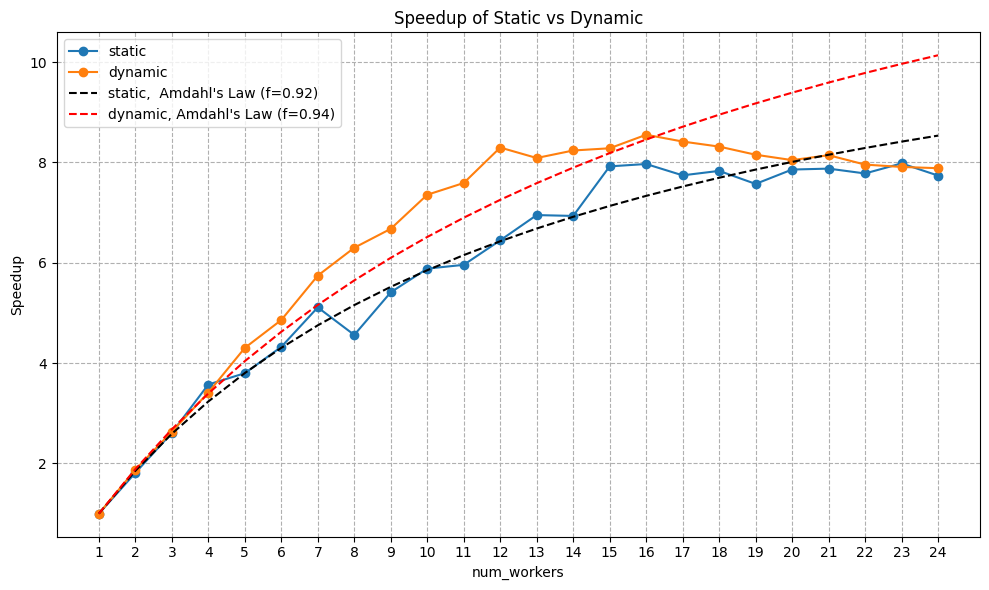

In [8]:
static_speedup = static_scheduling[0] / static_scheduling
dynamic_speedup = dynamic_scheduling[0] / dynamic_scheduling
p_static, p_dynamic = np.mean((1/static_speedup[1:] - 1) * (x_lim[1:]/(1-x_lim[1:]))), np.mean((1/dynamic_speedup[1:] - 1) * (x_lim[1:]/(1-x_lim[1:])))
plt.figure(figsize=(10, 6))
plt.plot(x_lim, static_speedup, 'o-', label='static')
plt.plot(x_lim, dynamic_speedup, 'o-', label='dynamic')
plt.plot(x_lim, 1/(1 - p_static + p_static/x_lim), 'k--', label=f'static,  Amdahl\'s Law (f={p_static:.2f})')
plt.plot(x_lim, 1/(1 - p_dynamic + p_dynamic/x_lim), 'r--', label=f'dynamic, Amdahl\'s Law (f={p_dynamic:.2f})')
plt.xlabel('num_workers')
plt.ylabel('Speedup')
plt.title('Speedup of Static vs Dynamic')
plt.legend()
plt.xticks(x_lim)
plt.grid(True, ls="--")
plt.tight_layout()
plt.show()

In [9]:
static_speedup

array([1.        , 1.81347701, 2.61055983, 3.57365744, 3.79844072,
       4.32314309, 5.11041109, 4.56163546, 5.41102776, 5.88300306,
       5.95785399, 6.44607839, 6.94969291, 6.93281188, 7.92038312,
       7.96740795, 7.74130899, 7.83038338, 7.57064031, 7.8570871 ,
       7.87545045, 7.77909874, 7.97945963, 7.7368067 ])

In [27]:
1/(1 - p_static), 1/(1 - p_dynamic)

(np.float64(12.689567975338893), np.float64(16.81102373618306))

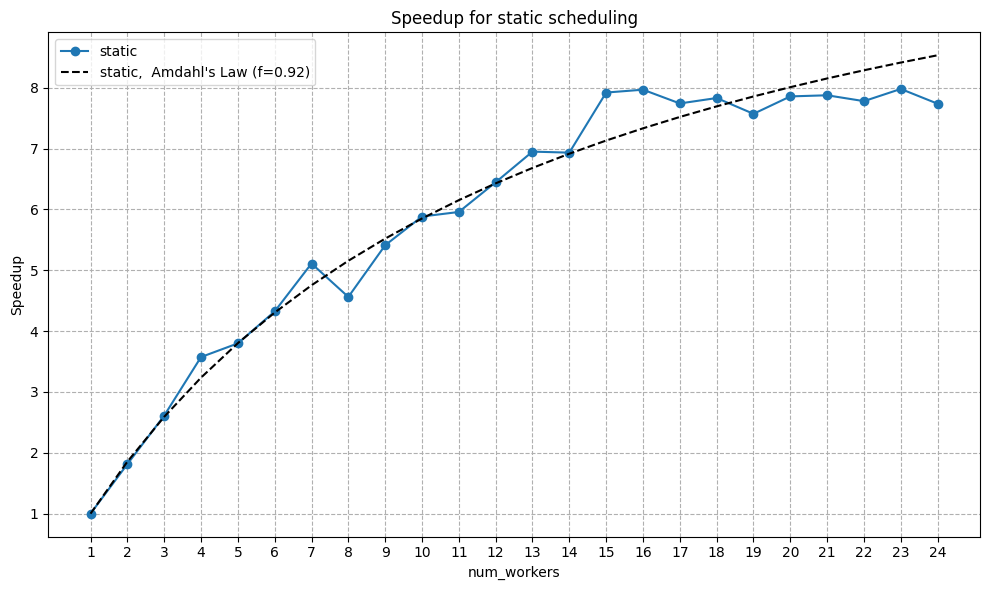

In [10]:
static_speedup = static_scheduling[0] / static_scheduling
# dynamic_speedup = dynamic_scheduling[0] / dynamic_scheduling
p_static, p_dynamic = np.mean((1/static_speedup[1:] - 1) * (x_lim[1:]/(1-x_lim[1:]))), np.mean((1/dynamic_speedup[1:] - 1) * (x_lim[1:]/(1-x_lim[1:])))
plt.figure(figsize=(10, 6))
plt.plot(x_lim, static_speedup, 'o-', label='static')
# plt.plot(x_lim, dynamic_speedup, 'o-', label='dynamic')
plt.plot(x_lim, 1/(1 - p_static + p_static/x_lim), 'k--', label=f'static,  Amdahl\'s Law (f={p_static:.2f})')
# plt.plot(x_lim, 1/(1 - p_dynamic + p_dynamic/x_lim), 'r--', label=f'dynamic, Amdahl\'s Law (f={p_dynamic:.2f})')
plt.xlabel('num_workers')
plt.ylabel('Speedup')
plt.title('Speedup for static scheduling')
plt.legend()
plt.xticks(x_lim)
plt.grid(True, ls="--")
plt.tight_layout()
plt.show()

In [16]:
idx = 8
(1/static_speedup[idx] - 1) * (x_lim[idx]/(1-x_lim[idx]))

np.float64(0.9170912531000338)

In [17]:
static_speedup[idx]

np.float64(5.411027755081829)

In [19]:
static_scheduling.min(), static_scheduling.argmin()

(np.float64(191.72), np.int64(22))